In [116]:
# 1. Definimos el punto (x0, y0) de donde partiremos
# por ejemplo, de punto (5, 3)
x0, y0 = (5, 3)

# 2. Generamos una lista vacía donde guardar los pasos aleatorios
pasos = []

# 3. Agregamos el punto de partida a los pasos, siendo el primer paso
pasos.append((x0, y0))

# 4. Suponemos que nos ubicamos actualmente en la posición (x, y)
# la cual será actualizada en cada paso que demos
x, y = (x0, y0)

# 5. Para cada paso que demos, buscamos una dirección aleatoria
# actualizamos la ubicación (x, y) y guardamos la posición
# a la que llegamos en la lista de pasos
import random
for i in range(10):
  # Calculamos una dirección aleatoria en x y y
  # podemos desplazarnos aleatoriamente entre (-1, 1) en x y y
  dx = random.uniform(-1, 1)
  dy = random.uniform(-1, 1)

  # Actualizamos la posición usando la posición actual
  # más la diferencia aleatoria en x o y
  x = x + dx
  y = y + dy

  # Guardamos el paso
  pasos.append((x, y))

# Así quedarían los 10 pasos más el inicial
pasos

[(5, 3),
 (4.1480148974213344, 3.514612286775998),
 (3.594429883841035, 3.2298009641055265),
 (3.0104630586871606, 4.0433960324364815),
 (3.959742977636057, 4.774766671426316),
 (4.138749371011867, 5.700985189535703),
 (4.509326732104805, 5.939529744152197),
 (5.250245207135621, 6.468527520343382),
 (4.926445080501328, 5.519044148804222),
 (5.221287665858374, 5.168598696300833),
 (6.067953341508294, 5.505578388682942)]

In [117]:
# 1. Definimos el punto (x1, y1) a donde queremos llegar
x1, y1 = (10, 10)

# 2. Definimos una función que mida la distancia entre el punto (x, y)
# y el punto (x1, y1)
def distancia(x, y, x1, y1):
  return ((x - x1) ** 2 + (y - y1) ** 2) ** 0.5

# 3. Acumulamos el error entre las distancias de cada paso y el punto (x1, y1)
# partiendo de 0
e = 0

# 4. Recorremos cada paso y calculamos el error entre el punto alcanzado
# en cada paso y el punto (x1, y1) usando la función de distancia
for x, y in pasos:
  # Calculamos la distancia entre los puntos
  d = distancia(x, y, x1, y1)

  # Acumulamos el error
  e = e + d

e

83.38074352922385

In [118]:
# 1. Primero creamos una copia de los pasos para no perder los originales
pasos_optimizados = pasos[:]

# 2. Definimos la función que mide el error
def error_pasos(pasos):
  return sum([distancia(x, y, x1, y1) for x, y in pasos])

# 3. Durante 5 épocas buscamos minimizar el error
for epoca in range(500):
  # Cramos una copia con los pasos de prueba
  pasos_prueba = pasos_optimizados[:]

  # Primero seleccionamos el índice de un paso a reemplazar
  # excepto para el primer punto que es el inicial
  i = random.choice(range(1, 11))

  # Luego obtenemos el punto anterior para tomar una dirección diferente
  j = i - 1
  xj, yj = pasos[j]

  # Suponemos que la ubicación actual es (xj, yj)
  x, y = xj, yj

  # Ahora calculamos nuevos pasos partiendo de xj, yj
  # hasta completar los pasos faltantes reemplazados
  for h in range(i, 11):
    dx = random.uniform(-1, 1)
    dy = random.uniform(-1, 1)

    x = x + dx
    y = y + dy

    # Reemplazamos el h-ésimo punto desde i hacia enfrente
    # en la lista con los pasos de prueba
    pasos_prueba[h] = (x, y)

  # Medimos el error entre los pasos y los nuevos pasos de prueba
  e_pasos = error_pasos(pasos_optimizados)
  e_prueba = error_pasos(pasos_prueba)

  # Si el error es menor en los pasos de prueba
  # reemplazamos los pasos
  if e_prueba < e_pasos:
    pasos_optimizados = pasos_prueba

  # Se repetirá en otra época

# Ahora se han alcanzado los mejores pasos en 5 épocas
pasos_optimizados

[(5, 3),
 (5.444496083659711, 3.708043525381724),
 (6.199825631654962, 3.3758500932674984),
 (6.775122720973741, 2.6795167207576736),
 (7.761703831768203, 3.5864201336618606),
 (8.415642637678571, 4.11146332034347),
 (4.878075713660015, 5.66817561267995),
 (5.371141224049505, 6.027628260431719),
 (5.892791569326985, 7.411017116765984),
 (6.645850634445081, 8.109747159154773),
 (7.481069536362924, 8.678887993190187)]

In [119]:
print("Error pasos originales:", error_pasos(pasos))
print("Error pasos optimizados:", error_pasos(pasos_optimizados))

Error pasos originales: 83.38074352922385
Error pasos optimizados: 69.25467425387073


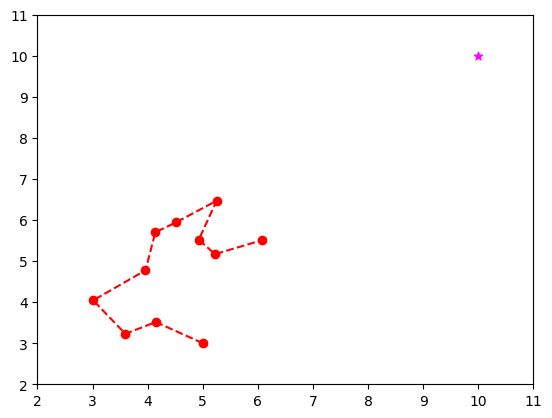

In [120]:
import matplotlib.pyplot as pyplot

X, Y = zip(*pasos)

pyplot.plot(X, Y, "ro--")
pyplot.scatter([10], [10], c="magenta", marker="*")
pyplot.xlim(2, 11)
pyplot.ylim(2, 11)
pyplot.show()

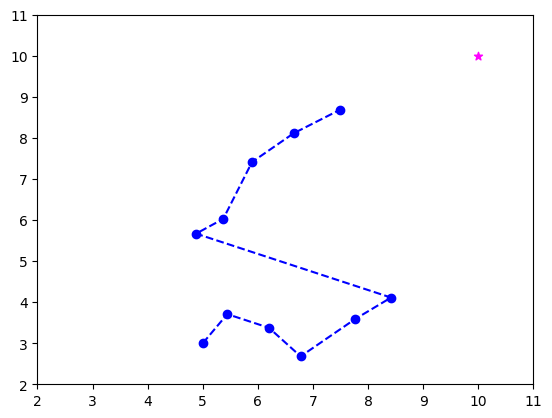

In [121]:
Xopt, Yopt = zip(*pasos_optimizados)
pyplot.plot(Xopt, Yopt, "bo--")
pyplot.scatter([10], [10], c="magenta", marker="*")
pyplot.xlim(2, 11)
pyplot.ylim(2, 11)
pyplot.show()

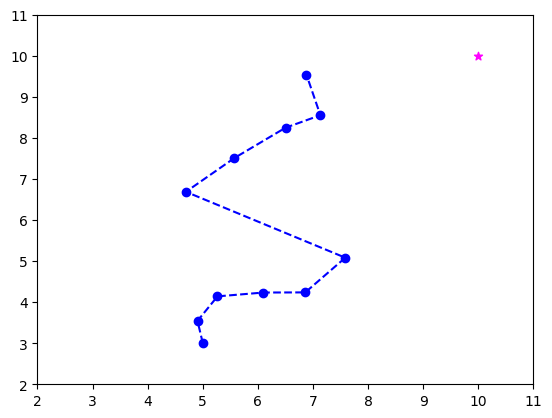

In [122]:
for epoca in range(5000):
  pasos_prueba = pasos_optimizados[:]

  i = random.choice(range(1, 11))

  j = i - 1
  xj, yj = pasos[j]

  x, y = xj, yj

  for h in range(i, 11):
    dx = random.uniform(-1, 1)
    dy = random.uniform(-1, 1)

    x = x + dx
    y = y + dy

    pasos_prueba[h] = (x, y)

  e_pasos = error_pasos(pasos_optimizados)
  e_prueba = error_pasos(pasos_prueba)

  if e_prueba < e_pasos:
    pasos_optimizados = pasos_prueba

Xopt, Yopt = zip(*pasos_optimizados)
pyplot.plot(Xopt, Yopt, "bo--")
pyplot.scatter([10], [10], c="magenta", marker="*")
pyplot.xlim(2, 11)
pyplot.ylim(2, 11)
pyplot.show()

In [123]:
# 1. Definimos las coordenadas iniciales de la máquina,
# para reportar su posición tras cada actualización
x, y = 0, 0

# 2. Definimos la dirección hacia donde apunta la máquina
# NORTE, SUR, ESTE u OESTE, por ejemplo, al avanzar
# si está viendo al NORTE, la coordenada y incrementará
d = "NORTE"

# 3. Creamos una memoria para recordar las coordenadas de la máquina
# en cada instrucción, inicializando la memoria en la primer coordenada
# y guardamos también la dirección en la memoria
memoria = [ (x, y, d) ]

# 4. Definimos una función que representa a la máquina
# y ejecuta una cinta de instrucciones, modificando
# las coordenadas y dirección donde se encuentra y apunta
def maquina(cinta, silencio = False):
  global x, y, d
  for i in cinta:
    if not silencio:
      print(f"INICIO: ({x}, {y}) [{d:5}] -> EJECUTA {i}")
    if i == "A":
      # Avanzar
      if d == "NORTE":
        y += 1
      elif d == "SUR":
        y -= 1
      if d == "ESTE":
        x += 1
      elif d == "OESTE":
        x -= 1
    elif i == "C":
      # Retroceder
      if d == "NORTE":
        y -= 1
      elif d == "SUR":
        y += 1
      elif d == "ESTE":
        x -= 1
      elif d == "OESTE":
        x += 1
    elif i == "B":
      # Girar izquierda
      if d == "NORTE":
        d = "OESTE"
      elif d == "SUR":
        d = "ESTE"
      elif d == "ESTE":
        d = "NORTE"
      elif d == "OESTE":
        d = "SUR"
    elif i == "D":
      # Girar derecha
      if d == "NORTE":
        d = "ESTE"
      elif d == "SUR":
        d = "OESTE"
      elif d == "ESTE":
        d = "SUR"
      elif d == "OESTE":
        d = "NORTE"
    else:
      if not silencio:
        print(">>> INSTRUCCIÓN NO VÁLIDA")
    if not silencio:
      print(f"FIN   : ({x}, {y}) [{d:5}]")
      print("-" * 40)
    memoria.append((x, y, d))

# 5. Ejecutamos la máquina con una cinta de instrucciones
maquina("ABCDEAABBCDDACDXDA")

INICIO: (0, 0) [NORTE] -> EJECUTA A
FIN   : (0, 1) [NORTE]
----------------------------------------
INICIO: (0, 1) [NORTE] -> EJECUTA B
FIN   : (0, 1) [OESTE]
----------------------------------------
INICIO: (0, 1) [OESTE] -> EJECUTA C
FIN   : (1, 1) [OESTE]
----------------------------------------
INICIO: (1, 1) [OESTE] -> EJECUTA D
FIN   : (1, 1) [NORTE]
----------------------------------------
INICIO: (1, 1) [NORTE] -> EJECUTA E
>>> INSTRUCCIÓN NO VÁLIDA
FIN   : (1, 1) [NORTE]
----------------------------------------
INICIO: (1, 1) [NORTE] -> EJECUTA A
FIN   : (1, 2) [NORTE]
----------------------------------------
INICIO: (1, 2) [NORTE] -> EJECUTA A
FIN   : (1, 3) [NORTE]
----------------------------------------
INICIO: (1, 3) [NORTE] -> EJECUTA B
FIN   : (1, 3) [OESTE]
----------------------------------------
INICIO: (1, 3) [OESTE] -> EJECUTA B
FIN   : (1, 3) [SUR  ]
----------------------------------------
INICIO: (1, 3) [SUR  ] -> EJECUTA C
FIN   : (1, 4) [SUR  ]
---------------

In [126]:
import numpy

mat = numpy.zeros((5, 5))

x, y = 0, 0
d = "NORTE"
memoria = [ (x, y, d) ]

maquina("AAAADAAAADABCCCBCCDABADA", silencio = True)

i = 1
for x, y, d in memoria:
  mat[y, x] = i
  i += 1

print(mat)

[[ 1.  0.  0.  0.  0.]
 [ 2. 20. 22.  0.  0.]
 [ 3. 18. 24. 25.  0.]
 [ 4. 17. 15. 14. 13.]
 [ 6.  7.  8.  9. 11.]]
